In [1]:
!pip -q install datasets

In [2]:
from huggingface_hub import login

login("")

In [3]:
from datasets import load_dataset

ds = load_dataset("Vacaspati/Vacaspati")

print(ds)

print("\nColumns:")
print(ds["train"].column_names)

print("\nSample:")
print(ds["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

vacaspati.zip:   0%|          | 0.00/337M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4667936 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 4667936
    })
})

Columns:
['text']

Sample:
{'text': 'সাময়িক পত্রে প্রকাশিত'}


In [5]:
import unicodedata
import re

count = 0

with open("bn_literature.txt", "w", encoding="utf-8") as out:

    for row in ds["train"]:

        text = row["text"]

        text = unicodedata.normalize("NFC", text)
        text = re.sub(r"\s+", " ", text).strip()

        if not text:
            continue

        out.write(text + "\n")
        count += 1

print("Saved documents:", count)

Saved documents: 4604919


In [6]:
import random

random.seed(42)

TARGET = 125000

with open("bn_literature.txt", encoding="utf-8") as f:
    total_docs = sum(1 for _ in f)

print("Total docs:", total_docs)

selected = set(
    random.sample(
        range(total_docs),
        TARGET
    )
)

count = 0

with open("bn_literature.txt", encoding="utf-8") as inp, \
     open("literature_125k.txt", "w", encoding="utf-8") as out:

    for idx, line in enumerate(inp):

        if idx in selected:
            out.write(line)
            count += 1

print("Saved:", count)

Total docs: 4604919
Saved: 125000


In [7]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    "ai4bharat/IndicCorpV2",
    repo_type="dataset"
)

print(len(files))
print(files[:20])

28
['.gitattributes', 'README.md', 'data/as.txt', 'data/bd.txt', 'data/bn.txt', 'data/dg.txt', 'data/en.txt', 'data/gom.txt', 'data/gu.txt', 'data/hi-1.txt', 'data/hi-2.txt', 'data/hi-3.txt', 'data/kha.txt', 'data/kn.txt', 'data/ks.txt', 'data/mai.txt', 'data/ml.txt', 'data/mni.txt', 'data/mr.txt', 'data/ne.txt']


In [8]:
from datasets import load_dataset

dataset = load_dataset(
    "ai4bharat/IndicCorpV2",
    data_files={"train": "data/bn.txt"}
)

print(dataset)

README.md:   0%|          | 0.00/4.01k [00:00<?, ?B/s]

data/bn.txt:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/33 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 41004792
    })
})


In [9]:
import unicodedata
import re

MAX_DOCS = 500000

with open("bn_news.txt", "w", encoding="utf-8") as f:

    for i, row in enumerate(dataset["train"]):

        text = unicodedata.normalize("NFC", row["text"])
        text = re.sub(r"\s+", " ", text).strip()

        if text:
            f.write(text + "\n")

        if i + 1 >= MAX_DOCS:
            break

print("Saved", MAX_DOCS, "documents")

Saved 500000 documents


In [12]:
import kagglehub

path = kagglehub.dataset_download(
    "mdsalmanhossain/bangla-social-media-abuse-dataset"
)

print(path)

100%|██████████| 4.44M/4.44M [00:01<00:00, 4.37MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/mdsalmanhossain/bangla-social-media-abuse-dataset/versions/1


In [13]:
import os

for root, dirs, files in os.walk(path):
    for f in files:
        print(f)

cyberbulling bangla dataset.xlsx


In [16]:
import pandas as pd
import os

file_path = os.path.join(
    path,
    "cyberbulling bangla dataset.xlsx"
)

xls = pd.ExcelFile(file_path)

print(xls.sheet_names)
df = pd.read_excel(
    file_path,
    sheet_name=0
)

print(df.columns.tolist())
print()
print("Rows:", len(df))

['Sheet1']
['comment', 'Category', 'Gender', 'comment react number', 'label']

Rows: 44001


In [18]:
import os

for f in os.listdir():
    if f.endswith(".txt"):
        print(f)

bn_news.txt
bn_literature.txt
literature_125k.txt


In [19]:
import random

random.seed(42)

TARGET = 125000

with open("bn_news.txt", encoding="utf-8") as f:
    total_docs = sum(1 for _ in f)

print("Total news docs:", total_docs)

selected = set(
    random.sample(
        range(total_docs),
        TARGET
    )
)

count = 0

with open("bn_news.txt", encoding="utf-8") as inp, \
     open("news_125k.txt", "w", encoding="utf-8") as out:

    for idx, line in enumerate(inp):

        if idx in selected:
            out.write(line)
            count += 1

print("Saved:", count)

Total news docs: 250000
Saved: 125000


In [20]:
print(df.columns.tolist())
print("Rows:", len(df))

['comment', 'Category', 'Gender', 'comment react number', 'label']
Rows: 44001


In [21]:
social_docs = [
    str(x).strip()
    for x in df["comment"]
    if pd.notna(x) and str(x).strip()
]

print("Social docs:", len(social_docs))

Social docs: 44001


In [22]:
with open(
    "social_44k.txt",
    "w",
    encoding="utf-8"
) as f:

    for doc in social_docs:
        f.write(doc + "\n")

print("Saved:", len(social_docs))

Saved: 44001


In [23]:
social_docs = [
    str(x).strip()
    for x in df["comment"]
    if pd.notna(x) and str(x).strip()
]

print("Original social:", len(social_docs))

Original social: 44001


In [24]:
social_125k = []

while len(social_125k) < 125000:
    social_125k.extend(social_docs)

social_125k = social_125k[:125000]

print("Expanded social:", len(social_125k))

Expanded social: 125000


In [25]:
with open("social_125k.txt", "w", encoding="utf-8") as f:
    for doc in social_125k:
        f.write(doc + "\n")

In [26]:
with open("news_125k.txt", encoding="utf-8") as f:
    count = sum(1 for _ in f)

print("News documents:", count)

News documents: 125000


In [27]:
with open("literature_125k.txt", encoding="utf-8") as f:
    literature_docs = [x.strip() for x in f if x.strip()]

with open("news_125k.txt", encoding="utf-8") as f:
    news_docs = [x.strip() for x in f if x.strip()]

all_docs = (
    literature_docs +
    news_docs +
    social_125k
)

import random
random.seed(42)
random.shuffle(all_docs)

print("Total documents:", len(all_docs))

Total documents: 375000


In [28]:
with open(
    "all_domains_375k.txt",
    "w",
    encoding="utf-8"
) as f:

    for doc in all_docs:
        f.write(doc.strip() + "\n")

print("Saved:", len(all_docs))

Saved: 375000


In [29]:
from collections import Counter

chars = 0
words = 0
vocab = Counter()

for doc in all_docs:

    chars += len(doc)

    ws = doc.split()

    words += len(ws)

    vocab.update(ws)

print("Documents :", len(all_docs))
print("Characters:", chars)
print("Words     :", words)
print("Vocabulary:", len(vocab))
print("TTR       :", len(vocab)/words)

avg_len = sum(len(w) for w in vocab) / len(vocab)

print("Average Word Length:", avg_len)

Documents : 375000
Characters: 66194162
Words     : 10548711
Vocabulary: 717244
TTR       : 0.06799352072494924
Average Word Length: 8.363121894362308


In [30]:
from sklearn.model_selection import train_test_split

train_docs, test_docs = train_test_split(
    all_docs,
    test_size=0.10,
    random_state=42
)

print("Train:", len(train_docs))
print("Test :", len(test_docs))

Train: 337500
Test : 37500


In [31]:
with open("train_all_bn.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(train_docs))

with open("test_all_bn.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(test_docs))

Transliteration

In [33]:
!pip install aksharamukha
from aksharamukha import transliterate
from tqdm import tqdm

def convert_file(inp, out):

    with open(inp, encoding="utf-8") as f:
        lines = [x.rstrip("\n") for x in f]

    with open(out, "w", encoding="utf-8") as f:

        for line in tqdm(lines):

            try:
                iso = transliterate.process(
                    "Bengali",
                    "ISO",
                    line
                )

            except:
                iso = line

            f.write(iso + "\n")

    print("Saved:", out)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 26.4 MB/s eta 0:00:00


In [34]:
convert_file(
    "train_all_bn.txt",
    "train_all_iso.txt"
)

convert_file(
    "test_all_bn.txt",
    "test_all_iso.txt"
)

100%|██████████| 337812/337812 [08:30<00:00, 661.14it/s]


Saved: train_all_iso.txt


100%|██████████| 37516/37516 [00:56<00:00, 667.34it/s]

Saved: test_all_iso.txt


In [35]:
from aksharamukha import transliterate
import random

with open(
    "test_all_bn.txt",
    encoding="utf-8"
) as f:

    samples = [
        x.strip()
        for x in f
        if x.strip()
    ]

samples = random.sample(samples, 100)

correct = 0

for s in samples:

    iso = transliterate.process(
        "Bengali",
        "ISO",
        s
    )

    back = transliterate.process(
        "ISO",
        "Bengali",
        iso
    )

    if s == back:
        correct += 1

print(
    "Exact Match:",
    correct,
    "/ 100"
)

print(
    "Accuracy:",
    correct / 100
)

Exact Match: 35 / 100
Accuracy: 0.35


In [36]:
for s in random.sample(samples, 10):

    iso = transliterate.process(
        "Bengali",
        "ISO",
        s
    )

    back = transliterate.process(
        "ISO",
        "Bengali",
        iso
    )

    print("="*80)
    print("ORIGINAL:")
    print(s)

    print("\nBACK:")
    print(back)

ORIGINAL:
বাকশক্তি হারিয়ে কেউ আর চিৎকার করতে চায়না,আপনার চেহেরা দেখেই বুজা যায় কি চিন্তাশক্তি ঢের দিচ্ছে! একবাক্য উচ্চারণে অনেকের মনে কিঞ্চিৎ ভাবিয়ে তুললেন, আপনি তো কোন কিছু না দেখে বিশ্বাস করেন না।জন্ম ও তো না দেখেই বাবা মাকে বিশ্বাস করেছেন নাকি সেখানেও গোল পাকিয়েছেন।প্লিজ জেনেশুনে ইসলাম নিয়ে খেলবেন না।ইমান টা কে মজবুত করুন।

BACK:
বাকশক্তি হারিয়ে কেউ আর চিৎকার করতে চায়না,আপনার চেহেরা দেখেই বুজা যায় কি চিন্তাশক্তি ঢের দিচ্ছে! একবাক্য উচ্চারণে অনেকের মনে কিঞ্চিৎ ভাবিয়ে তুললেন, আপনি তো কোন কিছু না দেখে বিশ্বাস করেন না।জন্ম ও তো না দেখেই বাবা মাকে বিশ্বাস করেছেন নাকি সেখানেও গোল পাকিয়েছেন।প্লিজ জেনেশুনে ইসলাম নিয়ে খেলবেন না।ইমান টা কে মজবুত করুন।
ORIGINAL:
রাত বাড়ছে, সাথে ভ্রমণের আনন্দটাও বাড়ছে। নগরীর রাস্তা ফাঁকা হতে শুরু করেছে। রংপুরের তাজহাট জমিদার বাড়ী শহর থেক তিন কিলোমিটার দূরে অবস্থিত। দূরত্ব দু’জন স্কাউট নেতার কাছে কোনো বিষয় নয়। তাছাড়া ওই দিকটায় গেলে দেখা মিলতে পারে পেয়ারা ভাইয়ের সাথে। তাই রিক্সা বদল করে ছুটে চরা তাজহাট জমিদার বাড়ীর দিকে। ইতাহাস ঘেঁটে জানা যায়, প্রাসাদট

In [37]:
from collections import Counter

def corpus_stats(path):

    chars = 0
    words = 0
    vocab = Counter()

    with open(path, encoding="utf-8") as f:

        for line in f:

            chars += len(line)

            ws = line.split()

            words += len(ws)

            vocab.update(ws)

    return {
        "chars": chars,
        "words": words,
        "vocab": len(vocab),
        "avg_word_len": chars / words
    }

bn = corpus_stats(
    "train_all_bn.txt"
)

iso = corpus_stats(
    "train_all_iso.txt"
)

print("Bengali:", bn)
print("ISO:", iso)

print(
    "\nExpansion Factor:",
    iso["chars"] / bn["chars"]
)

print(
    "Vocabulary Ratio:",
    iso["vocab"] / bn["vocab"]
)

Bengali: {'chars': 60010553, 'words': 9507879, 'vocab': 672856, 'avg_word_len': 6.3116656196403005}
ISO: {'chars': 69192523, 'words': 9507795, 'vocab': 660920, 'avg_word_len': 7.277452132697434}

Expansion Factor: 1.1530059221417273
Vocabulary Ratio: 0.9822606917379053


Tokenization

In [38]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [39]:
VOCABS = [
    5000,
    10000,
    15000,
    20000,
    25000,
    30000,
    35000,
    40000,
    45000,
    50000
]

In [40]:
for vocab_size in VOCABS:

    tokenizer = Tokenizer(
        BPE(unk_token="[UNK]")
    )

    tokenizer.pre_tokenizer = Whitespace()

    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]"]
    )

    tokenizer.train(
        ["train_all_bn.txt"],
        trainer
    )

    tokenizer.save(
        f"bpe_bn_{vocab_size}.json"
    )

    print(
        f"Finished {vocab_size}"
    )

Finished 5000
Finished 10000
Finished 15000
Finished 20000
Finished 25000
Finished 30000
Finished 35000
Finished 40000
Finished 45000
Finished 50000


In [41]:
from tokenizers import Tokenizer
import numpy as np

def evaluate_tokenizer(tokenizer_path, test_file):

    tok = Tokenizer.from_file(tokenizer_path)

    total_words = 0
    total_tokens = 0
    total_chars = 0

    unk_count = 0

    fertilities = []
    token_lengths = []

    with open(test_file, encoding="utf-8") as f:

        for line in f:

            ws = line.strip().split()

            for w in ws:

                total_words += 1
                total_chars += len(w)

                enc = tok.encode(w)

                tks = enc.tokens

                n_tok = len(tks)

                total_tokens += n_tok

                fertilities.append(n_tok)

                for t in tks:
                    token_lengths.append(len(t))

                unk_count += tks.count("[UNK]")

    fertility = total_tokens / total_words

    avg_token_len = np.mean(token_lengths)

    cpt = total_chars / total_tokens

    compression = cpt

    avg_tokens = fertility

    wfr = (total_tokens - total_words) / total_words

    variance = np.var(fertilities)

    return {
        "oov": unk_count / total_words,
        "fertility": fertility,
        "cpt": cpt,
        "compression": compression,
        "avg_tokens": avg_tokens,
        "wfr": wfr,
        "variance": variance
    }

In [42]:
results = []

for vocab_size in VOCABS:

    r = evaluate_tokenizer(
        f"bpe_bn_{vocab_size}.json",
        "test_all_bn.txt"
    )

    r["vocab"] = vocab_size

    results.append(r)

    print(r)

print("\nFinished.")

{'oov': 8.262620672692615e-05, 'fertility': 1.8117092864170203, 'cpt': 2.9245409493101975, 'compression': 2.9245409493101975, 'avg_tokens': 1.8117092864170203, 'wfr': 0.8117092864170202, 'variance': np.float64(1.428357289401865), 'vocab': 5000}
{'oov': 8.262620672692615e-05, 'fertility': 1.5682194628912254, 'cpt': 3.378620226153666, 'compression': 3.378620226153666, 'avg_tokens': 1.5682194628912254, 'wfr': 0.5682194628912255, 'variance': np.float64(0.9864801207470641), 'vocab': 10000}
{'oov': 8.262620672692615e-05, 'fertility': 1.4721780268093219, 'cpt': 3.599033472776041, 'compression': 3.599033472776041, 'avg_tokens': 1.4721780268093219, 'wfr': 0.47217802680932175, 'variance': np.float64(0.8124695736683193), 'vocab': 15000}
{'oov': 8.262620672692615e-05, 'fertility': 1.4178090220131587, 'cpt': 3.7370463257800868, 'compression': 3.7370463257800868, 'avg_tokens': 1.4178090220131587, 'wfr': 0.4178090220131587, 'variance': np.float64(0.7115757474848575), 'vocab': 20000}
{'oov': 8.2626206

In [43]:
for vocab_size in VOCABS:

    tokenizer = Tokenizer(
        BPE(unk_token="[UNK]")
    )

    tokenizer.pre_tokenizer = Whitespace()

    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]"]
    )

    tokenizer.train(
        ["train_all_iso.txt"],
        trainer
    )

    tokenizer.save(
        f"bpe_iso_{vocab_size}.json"
    )

    print(vocab_size)

5000
10000
15000
20000
25000
30000
35000
40000
45000
50000


In [44]:
results = []

for vocab_size in VOCABS:

    r = evaluate_tokenizer(
        f"bpe_iso_{vocab_size}.json",
        "test_all_iso.txt"
    )

    r["vocab"] = vocab_size

    results.append(r)

    print(r)

{'oov': 8.358882369387659e-05, 'fertility': 1.796504449903873, 'cpt': 3.4843658580674695, 'compression': 3.4843658580674695, 'avg_tokens': 1.796504449903873, 'wfr': 0.7965044499038728, 'variance': np.float64(1.3414350207287218), 'vocab': 5000}
{'oov': 8.358882369387659e-05, 'fertility': 1.5631177286130309, 'cpt': 4.004611203959415, 'compression': 4.004611203959415, 'avg_tokens': 1.5631177286130309, 'wfr': 0.5631177286130308, 'variance': np.float64(0.9414597928105541), 'vocab': 10000}
{'oov': 8.358882369387659e-05, 'fertility': 1.4706194892626794, 'cpt': 4.25649110107315, 'compression': 4.25649110107315, 'avg_tokens': 1.4706194892626794, 'wfr': 0.4706194892626793, 'variance': np.float64(0.7843742787311678), 'vocab': 15000}
{'oov': 8.358882369387659e-05, 'fertility': 1.419069204820481, 'cpt': 4.411115925740362, 'compression': 4.411115925740362, 'avg_tokens': 1.419069204820481, 'wfr': 0.419069204820481, 'variance': np.float64(0.6984616446093818), 'vocab': 20000}
{'oov': 8.358882369387659e

In [45]:
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.trainers import WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace

VOCABS = [
    5000,10000,15000,20000,25000,
    30000,35000,40000,45000,50000
]

for vocab_size in VOCABS:

    tok = Tokenizer(
        WordPiece(
            unk_token="[UNK]"
        )
    )

    tok.pre_tokenizer = Whitespace()

    trainer = WordPieceTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]"]
    )

    tok.train(
        ["train_all_bn.txt"],
        trainer
    )

    tok.save(
        f"wp_bn_{vocab_size}.json"
    )

    print(vocab_size)

5000
10000
15000
20000
25000
30000
35000
40000
45000
50000


In [46]:
results = []

for vocab_size in VOCABS:

    r = evaluate_tokenizer(
        f"wp_bn_{vocab_size}.json",
        "test_all_bn.txt"
    )

    r["vocab"] = vocab_size

    results.append(r)

    print(r)

print("\nFinished.")

{'oov': 3.266617475250569e-05, 'fertility': 2.0034126544917914, 'cpt': 2.644696280864908, 'compression': 2.644696280864908, 'avg_tokens': 2.0034126544917914, 'wfr': 1.0034126544917912, 'variance': np.float64(1.8403487577738247), 'vocab': 5000}
{'oov': 3.266617475250569e-05, 'fertility': 1.6508062780544794, 'cpt': 3.2095940431099304, 'compression': 3.2095940431099304, 'avg_tokens': 1.6508062780544794, 'wfr': 0.6508062780544795, 'variance': np.float64(1.1959152325941715), 'vocab': 10000}
{'oov': 3.266617475250569e-05, 'fertility': 1.5287961938141794, 'cpt': 3.46574515151896, 'compression': 3.46574515151896, 'avg_tokens': 1.5287961938141794, 'wfr': 0.5287961938141794, 'variance': np.float64(0.9652440744318022), 'vocab': 15000}
{'oov': 3.266617475250569e-05, 'fertility': 1.461238701346615, 'cpt': 3.6259770504910236, 'compression': 3.6259770504910236, 'avg_tokens': 1.461238701346615, 'wfr': 0.46123870134661504, 'variance': np.float64(0.8335333792265497), 'vocab': 20000}
{'oov': 3.2666174752

In [47]:
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.trainers import WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace

for vocab_size in VOCABS:

    tok = Tokenizer(
        WordPiece(
            unk_token="[UNK]"
        )
    )

    tok.pre_tokenizer = Whitespace()

    trainer = WordPieceTrainer(
        vocab_size=vocab_size,
        special_tokens=["[UNK]"]
    )

    tok.train(
        ["train_all_iso.txt"],
        trainer
    )

    tok.save(
        f"wp_iso_{vocab_size}.json"
    )

    print(vocab_size)

5000
10000
15000
20000
25000
30000
35000
40000
45000
50000


In [48]:
results = []

for vocab_size in VOCABS:

    r = evaluate_tokenizer(
        f"wp_iso_{vocab_size}.json",
        "test_all_iso.txt"
    )

    r["vocab"] = vocab_size

    results.append(r)

    print(r)

print("\nFinished.")

{'oov': 3.362768769293886e-05, 'fertility': 1.9866988083308272, 'cpt': 3.150794042288954, 'compression': 3.150794042288954, 'avg_tokens': 1.9866988083308272, 'wfr': 0.9866988083308272, 'variance': np.float64(1.7694580449463175), 'vocab': 5000}
{'oov': 3.362768769293886e-05, 'fertility': 1.650597756168519, 'cpt': 3.7923708218540977, 'compression': 3.7923708218540977, 'avg_tokens': 1.650597756168519, 'wfr': 0.6505977561685189, 'variance': np.float64(1.1690473762294522), 'vocab': 10000}
{'oov': 3.362768769293886e-05, 'fertility': 1.5303912629502627, 'cpt': 4.09024732475539, 'compression': 4.09024732475539, 'avg_tokens': 1.5303912629502627, 'wfr': 0.5303912629502627, 'variance': np.float64(0.9404866106711107), 'vocab': 15000}
{'oov': 3.362768769293886e-05, 'fertility': 1.4646424079730287, 'cpt': 4.27386147979583, 'compression': 4.27386147979583, 'avg_tokens': 1.4646424079730287, 'wfr': 0.4646424079730287, 'variance': np.float64(0.8167964275237927), 'vocab': 20000}
{'oov': 3.362768769293886

In [49]:
from tokenizers import Tokenizer
from tokenizers.models import Unigram
from tokenizers.trainers import UnigramTrainer
from tokenizers.pre_tokenizers import Whitespace

for vocab_size in VOCABS:

    tok = Tokenizer(
        Unigram()
    )

    tok.pre_tokenizer = Whitespace()

    trainer = UnigramTrainer(
        vocab_size=vocab_size,
        unk_token="[UNK]",
        special_tokens=["[UNK]"]
    )

    tok.train(
        ["train_all_bn.txt"],
        trainer
    )

    tok.save(
        f"uni_bn_{vocab_size}.json"
    )

    print(vocab_size)

5000
10000
15000
20000
25000
30000
35000
40000
45000
50000


In [50]:
results = []

for vocab_size in VOCABS:

    r = evaluate_tokenizer(
        f"uni_bn_{vocab_size}.json",
        "test_all_bn.txt"
    )

    r["vocab"] = vocab_size

    results.append(r)

    print(r)

print("\nFinished.")

{'oov': 0.0, 'fertility': 1.8066642839574494, 'cpt': 2.932707555808925, 'compression': 2.932707555808925, 'avg_tokens': 1.8066642839574494, 'wfr': 0.8066642839574494, 'variance': np.float64(1.5261570107959386), 'vocab': 5000}
{'oov': 0.0, 'fertility': 1.5781586269445982, 'cpt': 3.357341845052776, 'compression': 3.357341845052776, 'avg_tokens': 1.5781586269445982, 'wfr': 0.5781586269445982, 'variance': np.float64(1.0528094790495075), 'vocab': 10000}
{'oov': 0.0, 'fertility': 1.492707756871426, 'cpt': 3.5495347109853004, 'compression': 3.5495347109853004, 'avg_tokens': 1.492707756871426, 'wfr': 0.49270775687142593, 'variance': np.float64(0.8591517669274716), 'vocab': 15000}
{'oov': 0.0, 'fertility': 1.4464889626760131, 'cpt': 3.662950864533407, 'compression': 3.662950864533407, 'avg_tokens': 1.4464889626760131, 'wfr': 0.446488962676013, 'variance': np.float64(0.7557124005268895), 'vocab': 20000}
{'oov': 0.0, 'fertility': 1.4185930102072188, 'cpt': 3.7349810398390266, 'compression': 3.734

In [51]:
for vocab_size in VOCABS:

    tok = Tokenizer(
        Unigram()
    )

    tok.pre_tokenizer = Whitespace()

    trainer = UnigramTrainer(
        vocab_size=vocab_size,
        unk_token="[UNK]",
        special_tokens=["[UNK]"]
    )

    tok.train(
        ["train_all_iso.txt"],
        trainer
    )

    tok.save(
        f"uni_iso_{vocab_size}.json"
    )

    print(vocab_size)

5000
10000
15000
20000
25000
30000
35000
40000
45000
50000


In [52]:
results = []

for vocab_size in VOCABS:

    r = evaluate_tokenizer(
        f"uni_iso_{vocab_size}.json",
        "test_all_iso.txt"
    )

    r["vocab"] = vocab_size

    results.append(r)

    print(r)

print("\nFinished.")

{'oov': 0.0, 'fertility': 1.83339306251195, 'cpt': 3.4142590026684667, 'compression': 3.4142590026684667, 'avg_tokens': 1.83339306251195, 'wfr': 0.8333930625119499, 'variance': np.float64(1.6170203729963388), 'vocab': 5000}
{'oov': 0.0, 'fertility': 1.6043837053676515, 'cpt': 3.901609539020407, 'compression': 3.901609539020407, 'avg_tokens': 1.6043837053676515, 'wfr': 0.6043837053676515, 'variance': np.float64(1.114348203086147), 'vocab': 10000}
{'oov': 0.0, 'fertility': 1.518234373453727, 'cpt': 4.122998977339463, 'compression': 4.122998977339463, 'avg_tokens': 1.518234373453727, 'wfr': 0.5182343734537269, 'variance': np.float64(0.9230110317487729), 'vocab': 15000}
{'oov': 0.0, 'fertility': 1.472744759124873, 'cpt': 4.2503486977817735, 'compression': 4.2503486977817735, 'avg_tokens': 1.472744759124873, 'wfr': 0.47274475912487307, 'variance': np.float64(0.8177111140992007), 'vocab': 20000}
{'oov': 0.0, 'fertility': 1.4447943859055792, 'cpt': 4.3325741227793095, 'compression': 4.3325741

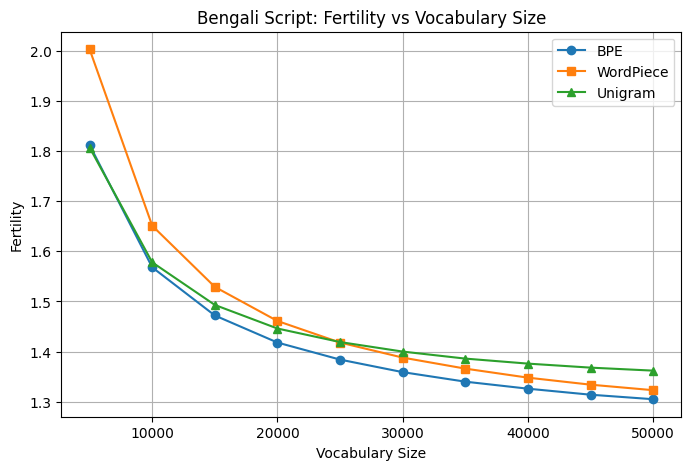

In [53]:
import matplotlib.pyplot as plt

vocab = [5000,10000,15000,20000,25000,30000,35000,40000,45000,50000]

bpe = [1.812,1.568,1.472,1.418,1.384,1.359,1.340,1.326,1.314,1.305]
wp  = [2.003,1.651,1.529,1.461,1.418,1.388,1.366,1.348,1.334,1.323]
uni = [1.807,1.578,1.493,1.446,1.419,1.400,1.386,1.376,1.368,1.362]

plt.figure(figsize=(8,5))
plt.plot(vocab,bpe,marker='o',label='BPE')
plt.plot(vocab,wp,marker='s',label='WordPiece')
plt.plot(vocab,uni,marker='^',label='Unigram')

plt.xlabel("Vocabulary Size")
plt.ylabel("Fertility")
plt.title("Bengali Script: Fertility vs Vocabulary Size")
plt.legend()
plt.grid(True)
plt.show()

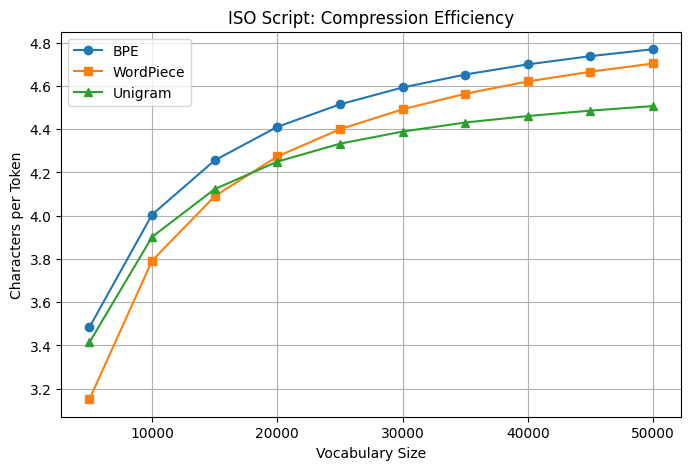

In [54]:
import matplotlib.pyplot as plt

vocab=[5000,10000,15000,20000,25000,30000,35000,40000,45000,50000]

bpe=[3.484,4.005,4.256,4.411,4.515,4.593,4.653,4.700,4.738,4.770]
wp=[3.151,3.792,4.090,4.274,4.400,4.492,4.564,4.621,4.666,4.704]
uni=[3.414,3.902,4.123,4.250,4.333,4.389,4.431,4.461,4.486,4.507]

plt.figure(figsize=(8,5))
plt.plot(vocab,bpe,marker='o',label='BPE')
plt.plot(vocab,wp,marker='s',label='WordPiece')
plt.plot(vocab,uni,marker='^',label='Unigram')

plt.xlabel("Vocabulary Size")
plt.ylabel("Characters per Token")
plt.title("ISO Script: Compression Efficiency")
plt.legend()
plt.grid(True)
plt.show()

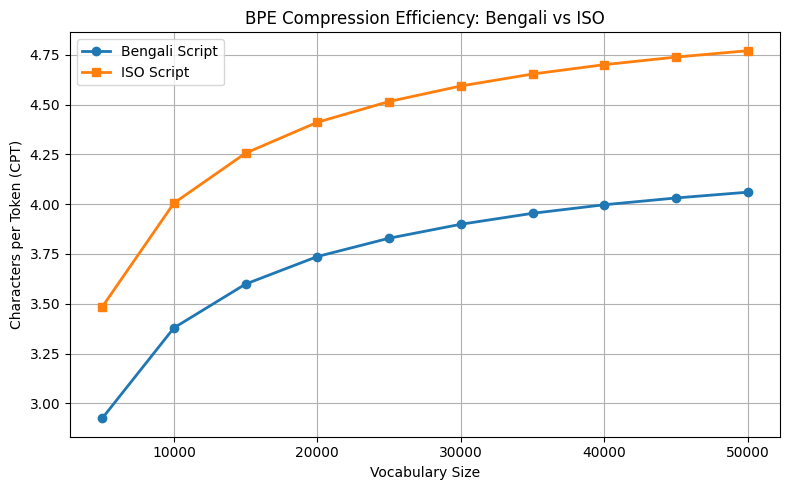

In [55]:
import matplotlib.pyplot as plt

vocab = [5000,10000,15000,20000,25000,30000,35000,40000,45000,50000]

bpe_bn = [2.925,3.379,3.599,3.737,3.829,3.899,3.954,3.997,4.031,4.060]
bpe_iso = [3.484,4.005,4.256,4.411,4.515,4.593,4.653,4.700,4.738,4.770]

plt.figure(figsize=(8,5))

plt.plot(
    vocab,
    bpe_bn,
    marker='o',
    linewidth=2,
    label='Bengali Script'
)

plt.plot(
    vocab,
    bpe_iso,
    marker='s',
    linewidth=2,
    label='ISO Script'
)

plt.xlabel('Vocabulary Size')
plt.ylabel('Characters per Token (CPT)')
plt.title('BPE Compression Efficiency: Bengali vs ISO')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

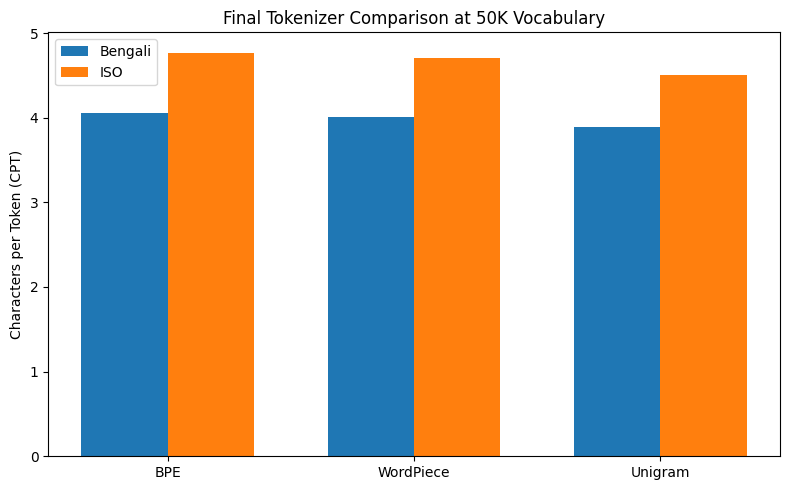

In [56]:
import matplotlib.pyplot as plt
import numpy as np

tokenizers = ['BPE', 'WordPiece', 'Unigram']

bn = [4.060, 4.004, 3.891]
iso = [4.770, 4.704, 4.507]

x = np.arange(len(tokenizers))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    bn,
    width,
    label='Bengali'
)

plt.bar(
    x + width/2,
    iso,
    width,
    label='ISO'
)

plt.xticks(x, tokenizers)
plt.ylabel('Characters per Token (CPT)')
plt.title('Final Tokenizer Comparison at 50K Vocabulary')
plt.legend()

plt.tight_layout()
plt.show()

# Observations and Findings

## Corpus Construction

A balanced multi-domain Bengali corpus was constructed by combining three distinct text sources:

* Literature: 125,000 documents
* News: 125,000 documents
* Social Media: 125,000 documents (expanded from the original 44,001 documents to ensure domain balance)

This resulted in a final corpus of 375,000 documents representing formal, semi-formal, and informal language usage.

### Corpus Statistics

| Metric                 |      Value |
| ---------------------- | ---------: |
| Documents              |    375,000 |
| Characters             | 66,194,162 |
| Words                  | 10,548,711 |
| Vocabulary             |    717,244 |
| Type-Token Ratio (TTR) |    0.06799 |
| Average Word Length    |       8.36 |

The combined corpus exhibits substantial lexical diversity, reflecting the heterogeneous nature of the included domains.

---

## Script Transformation Analysis

The Bengali corpus was transliterated into ISO script using Aksharamukha to investigate the effect of script representation on subword tokenization.

### Script Statistics

| Metric              |    Bengali |        ISO |
| ------------------- | ---------: | ---------: |
| Characters          | 60,010,553 | 69,192,523 |
| Words               |  9,507,879 |  9,507,795 |
| Vocabulary          |    672,856 |    660,920 |
| Average Word Length |       6.31 |       7.28 |

### Transliteration Metrics

| Metric               |  Value |
| -------------------- | -----: |
| Expansion Factor     | 1.1530 |
| Vocabulary Ratio     | 0.9823 |
| Exact Match Accuracy |    35% |

The ISO representation increased corpus length by approximately 15.3% while preserving most lexical distinctions. The relatively low exact-match accuracy is largely attributable to orthographic normalization and spelling variations present in social media text rather than semantic alterations introduced by the transliteration process.

---

# BPE Results

### Bengali Script

BPE demonstrated strong compression efficiency across all vocabulary sizes.

| Vocabulary Size | Fertility |   CPT |
| --------------: | --------: | ----: |
|              5k |     1.812 | 2.925 |
|             10k |     1.568 | 3.379 |
|             20k |     1.418 | 3.737 |
|             30k |     1.359 | 3.899 |
|             40k |     1.326 | 3.997 |
|             50k |     1.305 | 4.060 |

### ISO Script

| Vocabulary Size | Fertility |   CPT |
| --------------: | --------: | ----: |
|              5k |     1.797 | 3.484 |
|             10k |     1.563 | 4.005 |
|             20k |     1.419 | 4.411 |
|             30k |     1.363 | 4.593 |
|             40k |     1.332 | 4.700 |
|             50k |     1.312 | 4.770 |

The ISO representation consistently achieved higher compression values than Bengali across all vocabulary configurations. Fertility decreased steadily as vocabulary size increased, indicating the formation of larger and more informative subword units.

---

# WordPiece Results

### Bengali Script

| Vocabulary Size | Fertility |   CPT |
| --------------: | --------: | ----: |
|              5k |     2.003 | 2.645 |
|             10k |     1.651 | 3.210 |
|             20k |     1.461 | 3.626 |
|             30k |     1.388 | 3.816 |
|             40k |     1.348 | 3.930 |
|             50k |     1.323 | 4.004 |

### ISO Script

| Vocabulary Size | Fertility |   CPT |
| --------------: | --------: | ----: |
|              5k |     1.987 | 3.151 |
|             10k |     1.651 | 3.792 |
|             20k |     1.465 | 4.274 |
|             30k |     1.393 | 4.492 |
|             40k |     1.355 | 4.621 |
|             50k |     1.331 | 4.704 |

WordPiece followed trends similar to BPE but consistently produced slightly higher fertility and lower compression values. While effective, it remained marginally less efficient than BPE across all vocabulary sizes.

---

# Unigram Results

### Bengali Script

| Vocabulary Size | Fertility |   CPT |
| --------------: | --------: | ----: |
|              5k |     1.807 | 2.933 |
|             10k |     1.578 | 3.357 |
|             20k |     1.446 | 3.663 |
|             30k |     1.400 | 3.785 |
|             40k |     1.376 | 3.851 |
|             50k |     1.362 | 3.891 |

### ISO Script

| Vocabulary Size | Fertility |   CPT |
| --------------: | --------: | ----: |
|              5k |     1.833 | 3.414 |
|             10k |     1.604 | 3.902 |
|             20k |     1.473 | 4.250 |
|             30k |     1.426 | 4.389 |
|             40k |     1.403 | 4.461 |
|             50k |     1.389 | 4.507 |

Unigram produced the most fragmented segmentations among the evaluated tokenizers, resulting in higher fertility and lower compression values.

---

# Comparative Analysis

## Bengali Script (50k Vocabulary)

| Tokenizer |   CPT | Fertility |
| --------- | ----: | --------: |
| BPE       | 4.060 |     1.305 |
| WordPiece | 4.004 |     1.323 |
| Unigram   | 3.891 |     1.362 |

## ISO Script (50k Vocabulary)

| Tokenizer |   CPT | Fertility |
| --------- | ----: | --------: |
| BPE       | 4.770 |     1.312 |
| WordPiece | 4.704 |     1.331 |
| Unigram   | 4.507 |     1.389 |

Across both scripts, BPE consistently achieved the highest compression efficiency and lowest segmentation fragmentation. WordPiece produced comparable but slightly weaker results, while Unigram yielded the least compact tokenizations.

---

# Key Findings

1. BPE consistently outperformed WordPiece and Unigram across all intrinsic evaluation metrics.

2. ISO transliteration improved compression efficiency for every tokenizer family, increasing CPT values by approximately 16–18%.

3. Vocabulary expansion consistently reduced fertility and fragmentation, indicating more effective subword representation.

4. Performance gains diminished substantially beyond vocabulary sizes of 30k–40k, suggesting that larger vocabularies provide limited additional benefit.

5. The combination of multiple domains increased vocabulary diversity substantially, creating a more challenging and representative benchmark for Bengali tokenization.

6. Among all evaluated configurations, BPE trained on ISO-transliterated text with a vocabulary size between 30k and 40k provided the best overall balance between compression efficiency and vocabulary complexity.

## Conclusion

The multi-domain corpus experiment confirms that tokenizer performance is influenced by both corpus composition and script representation. BPE emerges as the most effective tokenizer for Bengali across diverse textual domains, while ISO script transformation consistently enhances tokenization compactness. These findings suggest that carefully selected vocabulary sizes and script representations can significantly improve the quality of subword tokenization for Bengali NLP applications.


In [57]:
pip install nbformat

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [62]:
import os

for root, dirs, files in os.walk("/content/drive"):
    for f in files:
        if f.endswith(".ipynb"):
            print(os.path.join(root, f))

/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Anasmita_AI.ipynb
/content/drive/MyDrive/Colab Notebooks/Anasmita.ipynb
/content/drive/MyDrive/Colab Notebooks/Anasmita_AI_final.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled22 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/Numba.ipynb
/content/drive/MyDrive/Colab Notebooks/SURGE_1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/HWOSS1.ipynb
/content/drive/MyDrive/Colab Notebooks/SURGE_3.ipynb
/content/drive/MyDrive/Colab Notebooks/SURGE_2.ipynb
/content/drive/MyDrive/Colab Notebooks/SURGE_4.ipynb
/content/dr

In [ ]:
import nbformat

path = "/content/drive/MyDrive/your_notebook.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

with open("fixed_notebook.ipynb", "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Fixed")